# Proyecto UD3
#### UD3. Aprendizaxe Non Supervisada
#### MP. Sistemas de Aprendizaxe Automáticos
#### IES de Teis (Vigo), Vanesa Resúa Eiras, Cristina Gómez Alonso
### Dataset: Países

Nuestro gallego de oro, Amancio Ortega, ha cumplido 89 años y le da vueltas a cuál será su legado en este mundo.
Es por ello, que ha contactado con el IES de Teis para que le ayudemos a identicar aquellos países más necesitados teniendo en cuenta factores socio-económicos y de salud para determinar el estado de cada país.
Una vez categorizados, la Fundación Ortega podrá abrir hospitales, escuelas y comedores sociales en dichos países.

Disponemos de un dataset con la información mundial de 166 países.

Lista de atributos para cada país:

* país: nombre del país
* mort_inf: número de niños menores de 5 años muertos por cada 1000 nacimientos
* exportaciones: exportaciones de bienes y servicios per cápita. Expresado como % del PIB per cápita
* salud: gasto total en salud per cápita. Expresado como % del PIB per cápita
* importaciones: importaciones de bienes y servicios per cápita. Expresado como % del PIB per cápita
* ingresos: ingresos netos por persona
* inflacion: la medida de la tasa de crecimiento anual del PIB total
* esp_vida: La cantidad promedio de años que viviría un niño recién nacido si los patrones de mortalidad actuales se mantuvieran iguales
* num_hijos: el número de hijos que nacerían de cada mujer si las tasas actuales de fecundidad por edad se mantuvieran iguales.
* pib: el PIB per cápita. Calculado como el PIB total dividido por la población total.

A Amancio no le interesan mucho los números ni las gráficas, sino que le extraigas conclusiones de cada uno de los pasos qué realizas y porqué los realizas.

## 1. Importación del dataset

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA
from yellowbrick.cluster import SilhouetteVisualizer


In [2]:
df_paises = pd.read_csv('doc/paises.csv')
df_paises

,pais,mort_inf,exportaciones,salud,importaciones,ingresos,inflacion,esp_vida,num_hijos,pib
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


In [3]:
df_paises.describe()

,mort_inf,exportaciones,salud,importaciones,ingresos,inflacion,esp_vida,num_hijos,pib
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


## 2. EDA&Preprocessing (2 puntos)

In [4]:
print(f"Nuestro dataframe tiene {df_paises.shape[0]} filas y {df_paises.shape[1]} columnas")

Nuestro dataframe tiene 167 filas y 10 columnas


In [5]:
df_paises.info()

<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   pais           167 non-null    str    
 1   mort_inf       167 non-null    float64
 2   exportaciones  167 non-null    float64
 3   salud          167 non-null    float64
 4   importaciones  167 non-null    float64
 5   ingresos       167 non-null    int64  
 6   inflacion      167 non-null    float64
 7   esp_vida       167 non-null    float64
 8   num_hijos      167 non-null    float64
 9   pib            167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 13.2 KB


<div style="
    background: linear-gradient(135deg, #4a90e2, #50c0f0);
    padding: 25px;
    border-radius: 12px;
    box-shadow: 0 8px 20px rgba(0, 0, 0, 0.15);
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    max-width: 700px;
">
<p style="
        color: #ffffff;
        font-size: 18px;
        line-height: 1.6;
        margin: 0;
        text-align: justify;
    ">
Vemos los tipos de datos de la columnas, para ver si hay datos categóricos
    </p>

</div>

In [6]:
df_paises.duplicated().sum()

np.int64(0)

<div style="
    background: linear-gradient(135deg, #4a90e2, #50c0f0);
    padding: 25px;
    border-radius: 12px;
    box-shadow: 0 8px 20px rgba(0, 0, 0, 0.15);
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    max-width: 700px;
">
<p style="
        color: #ffffff;
        font-size: 18px;
        line-height: 1.6;
        margin: 0;
        text-align: justify;
    ">
        Comprobamos que no haya duplicados, ya que el algoritmo le dará el doble de importancia a ese perfil dando a lugar a a sesgo en el resultado.
    </p>

</div>

In [7]:
df_paises.isnull().sum()


pais             0
mort_inf         0
exportaciones    0
salud            0
importaciones    0
ingresos         0
inflacion        0
esp_vida         0
num_hijos        0
pib              0
dtype: int64

<div style="
    background: linear-gradient(135deg, #4a90e2, #50c0f0);
    padding: 25px;
    border-radius: 12px;
    box-shadow: 0 8px 20px rgba(0, 0, 0, 0.15);
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    max-width: 700px;
">
<p style="
        color: #ffffff;
        font-size: 18px;
        line-height: 1.6;
        margin: 0;
        text-align: justify;
    ">
Comprobamos si hay nulos, en este dataset no tenemos nulos por lo tanto no hay que tratarlos. Si los hubieran tendríamos que haber rellenado esos nulos...
    </p>

</div>

<h2 style="
    background: linear-gradient(90deg, #4a90e2, #50c0f0);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    font-size: 28px;
    font-weight: 700;
    margin: 20px 0;
    border-bottom: 2px solid #50c0f0;
    display: inline-block;
    padding-bottom: 5px;
">
    2.1 Gráficos
</h2>

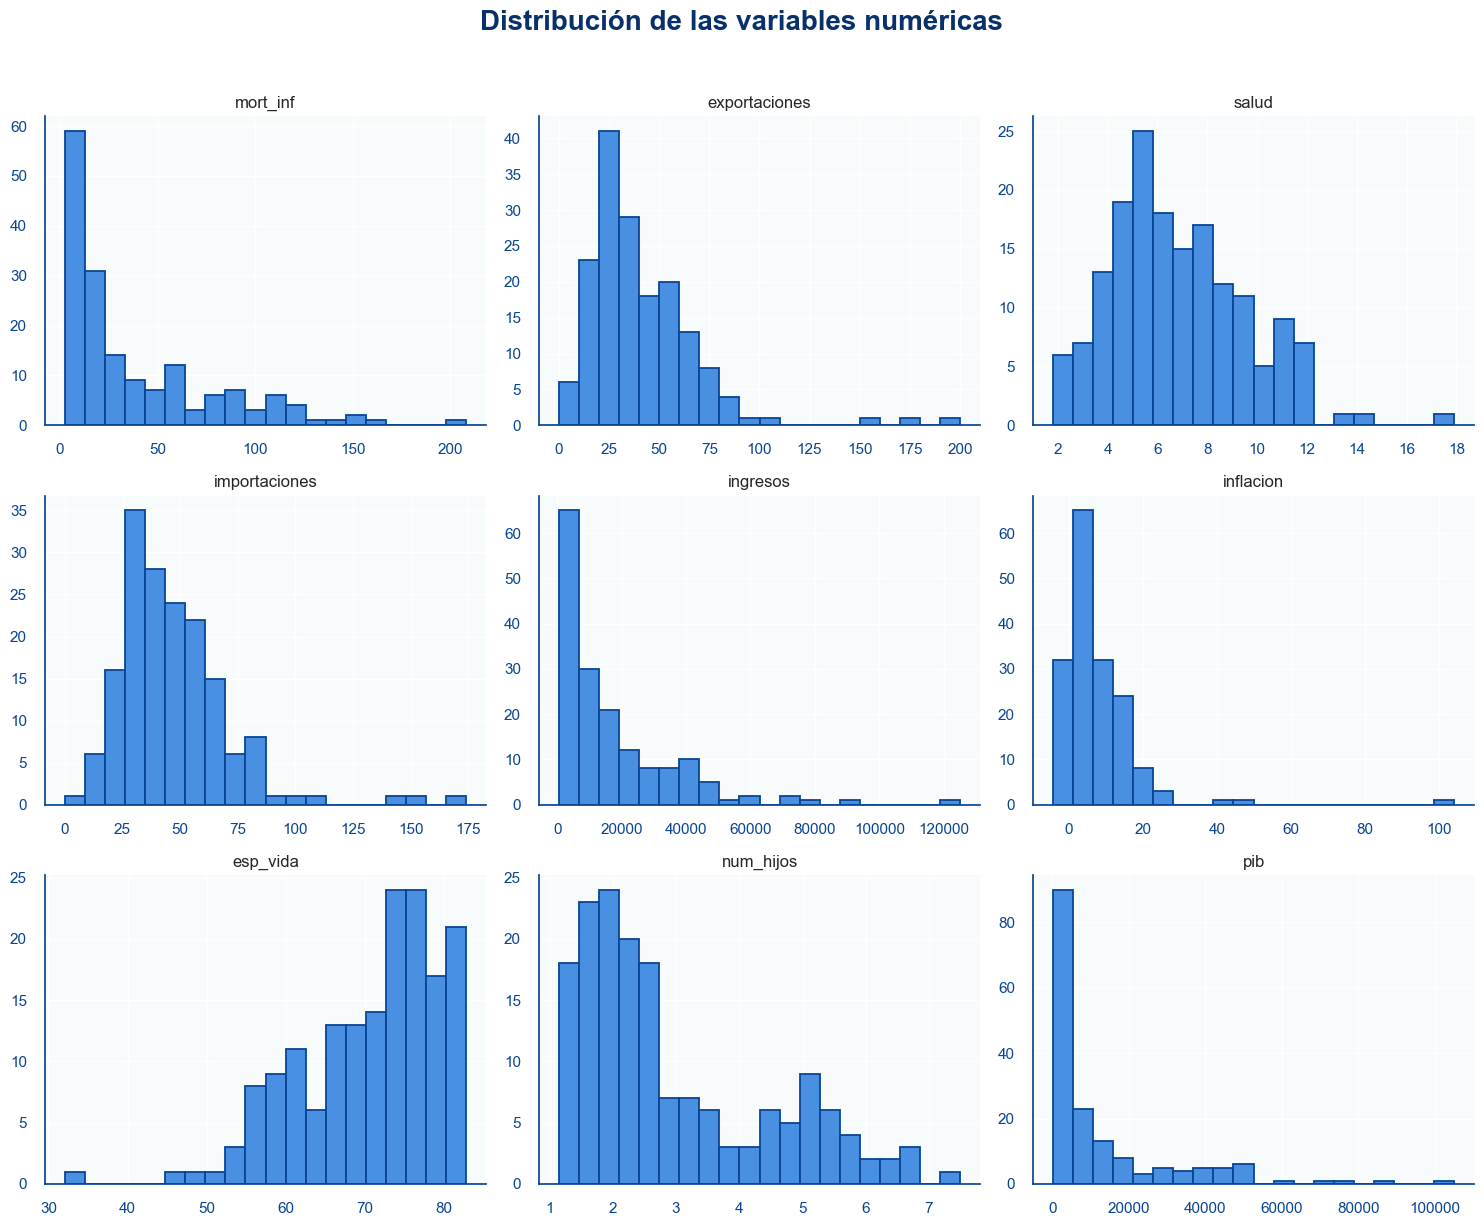

In [8]:
sns.set_theme(style="whitegrid")

color_barras = "#4a90e2"
color_borde = "#084594"

axes = df_paises.drop('pais', axis=1).hist(
    figsize=(15, 12),
    bins=20,
    color=color_barras,
    edgecolor=color_borde,
    linewidth=1.3
)

plt.suptitle(
    'Distribución de las variables numéricas', 
    fontsize=20, 
    fontweight='bold', 
    color='#08306b', 
    y=1.02
)

for ax_row in axes:
    for ax in ax_row:
        ax.set_facecolor('#f7fbfc')  # Fondo suave
        ax.grid(True, color='white', linewidth=1.0)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_color('#084594')
        ax.spines['bottom'].set_color('#084594')
        ax.tick_params(axis='x', colors='#084594')
        ax.tick_params(axis='y', colors='#084594')

plt.tight_layout()
plt.show()

<div style="
border-radius:12px;
padding:22px;
background:linear-gradient(180deg,#0b3d91,#072a63);
color:white;
box-shadow:0 6px 16px rgba(0,0,0,0.25);
font-family:Arial, sans-serif;
">

<h2 style="
color:white;
border-bottom:2px solid #4fa3ff;
padding-bottom:8px;
margin-top:0;">
Análisis de Distribución de Variables
</h2>

<h3 style="color:#8ecaff;">1.Valores Atípicos (Outliers)</h3>

La mayoría de variables presentan <b>valores extremos</b>.  
Esto ocurre especialmente en:

<ul>
<li><b>mortalidad_infantil</b></li>
<li><b>exportaciones</b></li>
<li><b>importaciones</b></li>
<li><b>ingresos</b></li>
<li><b>pib</b></li>
</ul>

✔ La variable <b>num_hijos</b> sería la más estable.

<hr style="border:1px solid #3d6fb6;">

<h3 style="color:#8ecaff;">2. Asimetría en Variables Económicas</h3>

Las variables <b>ingresos</b> y <b>pib</b> muestran una clara  
<b style="color:#7fc8ff;">asimetría positiva (sesgo a la derecha)</b>.

Esto indica que:

<ul>
<li>La mayoría de países tienen valores <b>bajos o medios</b>.</li>
<li>Un pequeño grupo de países muy ricos genera <b>valores extremadamente altos</b>.</li>
</ul>

<hr style="border:1px solid #3d6fb6;">

<h3 style="color:#8ecaff;">3. Relación entre Importaciones y Exportaciones</h3>

Las distribuciones de <b>importaciones</b> y <b>exportaciones</b> son visualmente muy similares.

Esto sugiere una posible  
<b style="color:#7fc8ff;">correlación positiva</b> entre ambas variables:

<ul>
<li>Los países que exportan mucho</li>
<li>también tienden a importar en grandes cantidades</li>
</ul>

<hr style="border:1px solid #3d6fb6;">

<h3 style="color:#8ecaff;">4. Esperanza de Vida</h3>

El <b>50% central de países</b> se encuentra aproximadamente entre:

<p style="
font-size:18px;
color:#7fc8ff;
font-weight:bold;">
60 – 80 años
</p>

Los valores inferiores aparecen como <b>outliers</b>, indicando países con menor desarrollo sanitario y social.

</div>

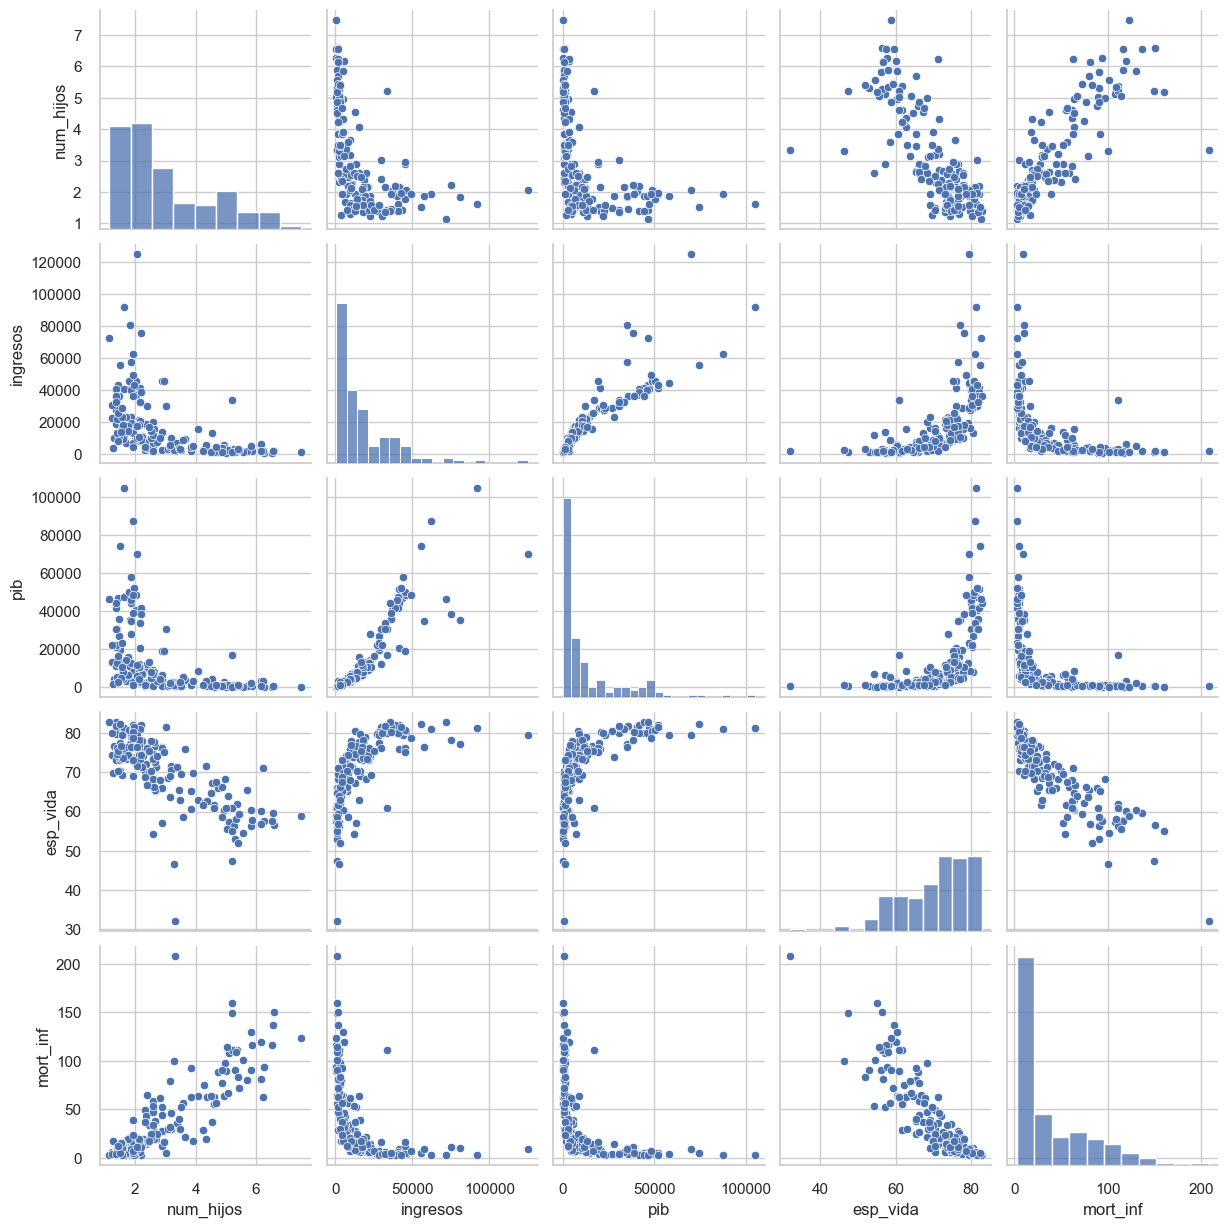

In [9]:
sns.pairplot(df_paises, vars=["num_hijos", "ingresos", "pib", "esp_vida", "mort_inf"])
plt.show()

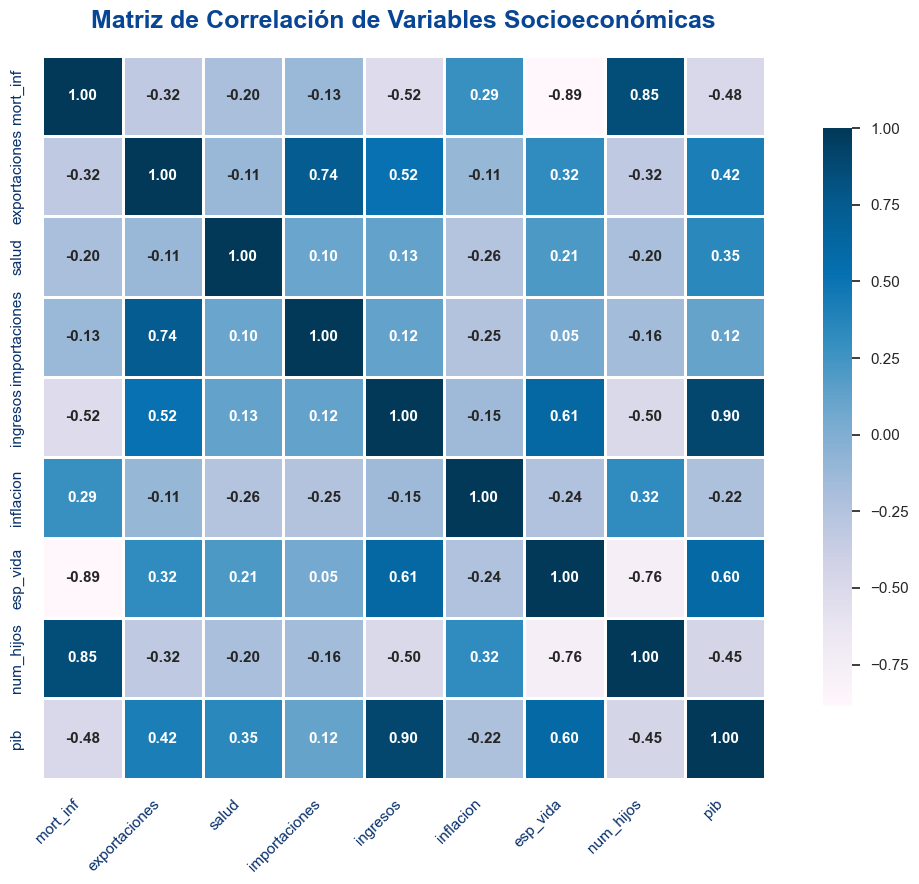

In [10]:
sns.set_theme(style="white")

corr_matrix = df_paises.drop('pais', axis=1).corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    corr_matrix, 
    annot=True,                              
    cmap='PuBu',                            
    fmt=".2f",                               
    linewidths=1,                        
    linecolor='white',                    
    cbar_kws={"shrink": .8},                 
    square=True,                            
    annot_kws={"size": 11, "weight": "bold"} 
)

plt.title('Matriz de Correlación de Variables Socioeconómicas', 
        fontsize=18, fontweight='bold', color='#084594', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11, color='#08306b')
plt.yticks(fontsize=11, color='#08306b')

plt.tight_layout()
plt.show()

<div style="
    background: #f8fcff;
    padding: 25px 30px;
    border-radius: 15px;
    box-shadow: 0 8px 25px rgba(0, 0, 0, 0.08);
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    color: #08306b;
    max-width: 850px;
    line-height: 1.7;
    border-left: 6px solid #4a90e2;
">

<h3 style="
        font-size: 22px;
        font-weight: bold;
        margin-bottom: 20px;
        color: #084594;
        text-align: center;
        text-transform: uppercase;
    ">
        Matriz de Correlación
    </h3>

<div style="
        background: #e0f1fb;
        border-radius: 10px;
        padding: 15px 20px;
        margin-bottom: 15px;
        border-left: 4px solid #4a90e2;
    ">
        <strong>Correlaciones Positivas Fuertes:</strong>
        <ul style="margin-top: 8px; margin-left: 20px;">
            <li><strong>ingresos y pib (0.90):</strong> Los países con mayor Producto Interior Bruto general suelen tener mayores ingresos por persona.</li>
            <li><strong>mort_inf y num_hijos (0.84):</strong> Los países menos desarrollados, las altas tasas de mortalidad infantil suelen ir acompañadas de altas tasas de natalidad.</li>
        </ul>
    </div>

<div style="
        background: #d3e8fb;
        border-radius: 10px;
        padding: 15px 20px;
        margin-bottom: 15px;
        border-left: 4px solid #3a78c2;
    ">
        <strong>Correlaciones Negativas Fuertes:</strong>
        <ul style="margin-top: 8px; margin-left: 20px;">
            <li><strong>esp_vida y mort_inf (-0.89):</strong> Los países donde mueren muchos niños en sus primeros años ven su esperanza de vida media reducida.</li>
            <li><strong>esp_vida y num_hijos (-0.76):</strong> A mayor número de hijos por mujer, menor suele ser la esperanza de vida del país</li>
        </ul>
    </div>

<div style="
        background: #d3e8fb;
        border-radius: 10px;
        padding: 15px 20px;
        margin-bottom: 15px;
        border-left: 4px solid #3a78c2;
    ">
        <strong>PCA:</strong>
        <ul style="margin-top: 8px; margin-left: 20px;">
            <li>El que haya correlaciones fuertes, muchas variables suben o bajan juntas por consiguiente es ideal aplicar el algoritmo de PCA </li>
        </ul>
    </div>



</div>

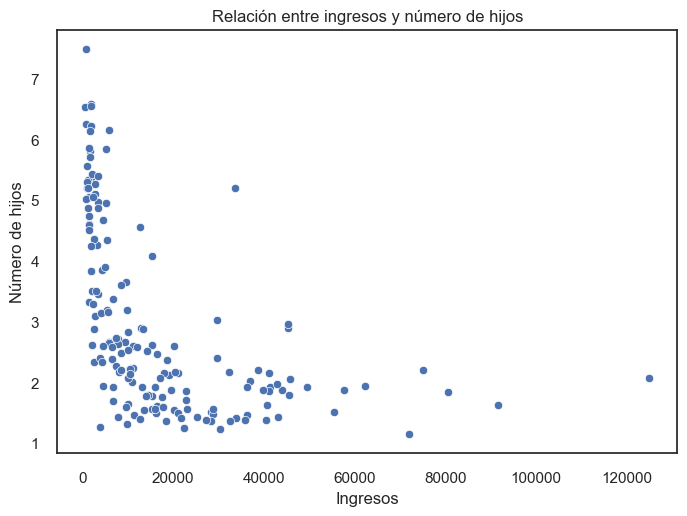

In [11]:
sns.scatterplot(data=df_paises, x="ingresos", y="num_hijos")
plt.title("Relación entre ingresos y número de hijos")
plt.xlabel("Ingresos")
plt.ylabel("Número de hijos")
plt.show()          

<div style="
    background: linear-gradient(135deg, #4a90e2, #50c0f0);
    padding: 25px;
    border-radius: 12px;
    box-shadow: 0 8px 20px rgba(0, 0, 0, 0.15);
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    max-width: 700px;
">
<p style="
        color: #ffffff;
        font-size: 18px;
        line-height: 1.6;
        margin: 0;
        text-align: justify;
    ">
        Como podemos ver los países con menores ingresos tienden a ser los que más hijos tienen.
    </p>

</div>

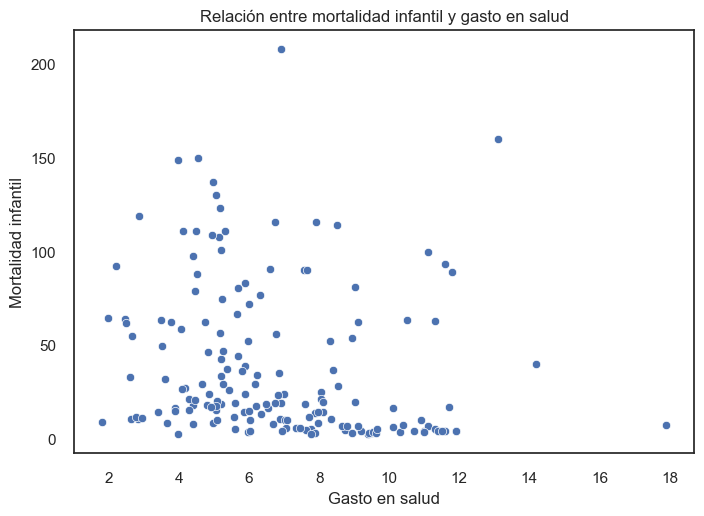

In [12]:
sns.scatterplot(data=df_paises, x="salud", y="mort_inf")
plt.title("Relación entre mortalidad infantil y gasto en salud")
plt.xlabel("Gasto en salud")
plt.ylabel("Mortalidad infantil")
plt.show()

<div style="
    background: linear-gradient(135deg, #4a90e2, #50c0f0);
    padding: 25px;
    border-radius: 12px;
    box-shadow: 0 8px 20px rgba(0, 0, 0, 0.15);
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    max-width: 700px;
">
<p style="
        color: #ffffff;
        font-size: 18px;
        line-height: 1.6;
        margin: 0;
        text-align: justify;
    ">
        Tener un elevado gasto en salud no implica una menor mortalidad infantil.
    </p>

</div>

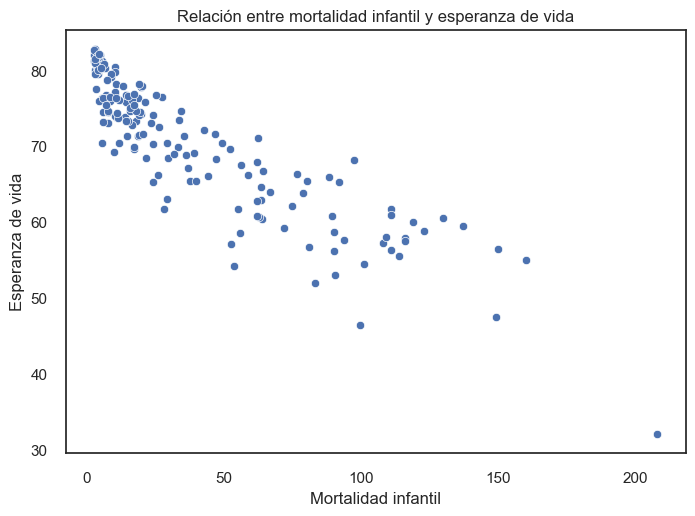

In [13]:
sns.scatterplot(data=df_paises, x="mort_inf", y="esp_vida")
plt.title("Relación entre mortalidad infantil y esperanza de vida")
plt.xlabel("Mortalidad infantil")
plt.ylabel("Esperanza de vida")
plt.show()  

<div style="
    background: linear-gradient(135deg, #4a90e2, #50c0f0);
    padding: 25px;
    border-radius: 12px;
    box-shadow: 0 8px 20px rgba(0, 0, 0, 0.15);
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    max-width: 700px;
">
<p style="
        color: #ffffff;
        font-size: 18px;
        line-height: 1.6;
        margin: 0;
        text-align: justify;
    ">
        Los países con una menor esperanza de vida suelen tener una mayor tasa de mortalidad infantil.
    </p>

</div>

------------

<div style="
border-radius:12px;
padding:22px;
background:linear-gradient(180deg,#0b3d91,#072a63);
color:white;
box-shadow:0 6px 16px rgba(0,0,0,0.25);
font-family:Arial, sans-serif;
">

<h2 style="
color:white;
border-bottom:2px solid #4fa3ff;
padding-bottom:8px;
margin-top:0;">
2.2 Preprocesado de los Datos
</h2>


<h3 style="color:#8ecaff;">🔹 Selección de Variables</h3>

Se seleccionaron únicamente las variables relevantes para el análisis, eliminando aquellas
que no aportan información útil al modelo o que podrían introducir ruido.

<hr style="border:1px solid #3d6fb6;">

<h3 style="color:#8ecaff;">🔹 Escalado de los Datos</h3>

Dado que las variables presentan <b>diferentes rangos de valores</b>, se aplicó un proceso de 
<b>normalización o estandarización</b>.  

Algoritmos que usaremos se basan en el cálculo de distancias por lo tanto debemos escalar y de esta manera evita que aquellas con 
valores más grandes dominen el proceso de aprendizaje.

<hr style="border:1px solid #3d6fb6;">

<h3 style="color:#8ecaff;">🔹 Preparación para Clustering</h3>

Tras el escalado, los datos quedan preparados para aplicar técnicas de 
<b>clustering</b>, permitiendo que los algoritmos identifiquen patrones y agrupaciones
entre los países basándose en sus características socioeconómicas.

</div>

<div style="
    background: linear-gradient(135deg, #064792, #50c0f0);
    padding: 25px;
    border-radius: 12px;
    box-shadow: 0 8px 20px rgba(0, 0, 0, 0.15);
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    max-width: 700px;
">
<p style="
        color: #ffffff;
        font-size: 18px;
        line-height: 1.6;
        margin: 0;
        text-align: justify;
    ">
        Los outliers presentes en nuestro dataset pueden distorsionar los clústers, pero en este caso, los outliers son importantes, por ejemplo un país con una mortalidad infatil alta es lo que básicamente Amancio esta buscando.
    </p>

</div>

<div style="
    background: linear-gradient(135deg, #064792, #50c0f0);
    padding: 25px;
    border-radius: 12px;
    box-shadow: 0 8px 20px rgba(0, 0, 0, 0.15);
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    max-width: 700px;
">
<p style="
        color: #ffffff;
        font-size: 18px;
        line-height: 1.6;
        margin: 0;
        text-align: justify;
    ">
        Los modelos no entienden texto de este modo, el nombre de país no es una característica para agrupar, es más bien una etiqueta por consiguiente lo paso a índice para saber al final qué país es cada cual al final.
    </p>

</div>

In [14]:

df_paises.set_index('pais', inplace=True)
# df_num = df_paises.drop('pais', axis=1)¿no se si borraralaaa¿?



In [15]:

scaler = StandardScaler()

df_scaled = scaler.fit_transform(df_paises)

df_scaled = pd.DataFrame(df_scaled, columns=df_paises.columns, index=df_paises.index)


## 3. Creación de los modelos, entrenamiento, predicciones y representación gráfica (4 puntos)

<h1 style="
    background: linear-gradient(90deg, #4a90e2, #50c0f0);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    font-size: 28px;
    font-weight: 700;
    margin: 20px 0;
    border-bottom: 2px solid #50c0f0;
    display: inline-block;
    padding-bottom: 5px;
">
    3.1 K-Means
</h1>

<div style="
    background: linear-gradient(135deg, #064792, #15546f);
    padding: 25px;
    border-radius: 12px;
    box-shadow: 0 8px 20px rgba(0, 0, 0, 0.15);
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    max-width: 700px;
">
<p style="
        color: #ffffff;
        font-size: 18px;
        line-height: 1.6;
        margin: 0;
        text-align: justify;
    ">
        Para este algoritmo necesitamos pasarle el parámetro K (cuántos grupos que queremos que forme), como no sabemos vamos a realizar varios métodos para obtener el mejor 
    </p>

</div>

<p style="
    background: linear-gradient(90deg, #4a90e2, #50c0f0);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    font-size: 16px;
    font-weight: 700;
    margin: 20px 0;
    border-bottom: 2px solid #50c0f0;
    display: inline-block;
    padding-bottom: 5px;
">
    Método ELBOW : Evalúa la inercia o distorsión, es decir en este caso mide lo lejos que están los países del centro de su propio clúster, buscamos una inercia baja -> clústers compactos
</p>

c:\Users\nicki\miniconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\nicki\miniconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\nicki\miniconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\nicki\miniconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarn

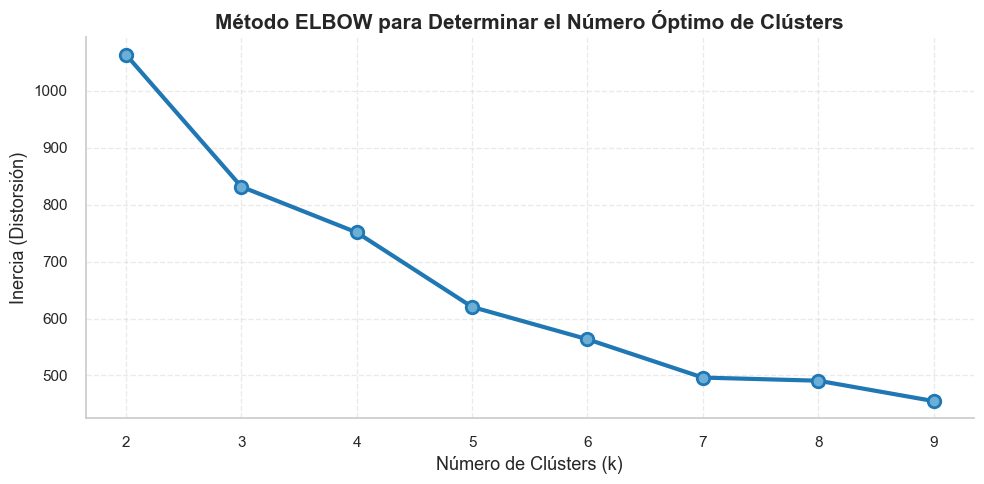

In [16]:
sns.set_style("whitegrid")

X = df_scaled

distortions = []
K_range = range(2, 10)

for k in K_range:
    kmeanModel = KMeans(n_clusters=k, n_init='auto', random_state=42)
    kmeanModel.fit(X)
    distortions.append(kmeanModel.inertia_)

plt.figure(figsize=(10,5))

blue_main = "#1f77b4"
blue_light = "#6baed6"

plt.plot(
    K_range,
    distortions,
    marker='o',
    markersize=9,
    linewidth=3,
    color=blue_main,
    markerfacecolor=blue_light,
    markeredgewidth=2
)

plt.xlabel("Número de Clústers (k)", fontsize=13)
plt.ylabel("Inercia (Distorsión)", fontsize=13)
plt.title("Método ELBOW para Determinar el Número Óptimo de Clústers", fontsize=15, weight="bold")

plt.xticks(K_range)
plt.grid(True, linestyle="--", alpha=0.4)

sns.despine()

plt.tight_layout()
plt.show()

<p style="
    background: linear-gradient(90deg, #4a90e2, #50c0f0);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    font-size: 16px;
    font-weight: 700;
    margin: 20px 0;
    border-bottom: 2px solid #50c0f0;
    display: inline-block;
    padding-bottom: 5px;
">
    Como vemos en la gráfica del método ELBOW sugiere un k = 3 , a partir de este empieza a suavizarse haciendo ese efecto codo que buscamos.
    
</p>

<p style="
    background: linear-gradient(90deg, #1758a3, #50c0f0);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    font-size: 16px;
    font-weight: 700;
    margin: 20px 0;
    display: inline-block;
    padding-bottom: 5px;
">
    Método Silhoutte Score : mide la cohesión y separación, es decir qué tan cerca está un país de los otros de su mismo clúster y qué tan lejos está de los países de los otros clústers.
    Se interpreta cuanto más cerca de 1, mejor, el valor va de -1 a 1. Buscamos que en nuestra gráfica el valor de K sea el valor más alto
</p>

c:\Users\nicki\miniconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\nicki\miniconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\nicki\miniconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\nicki\miniconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarn

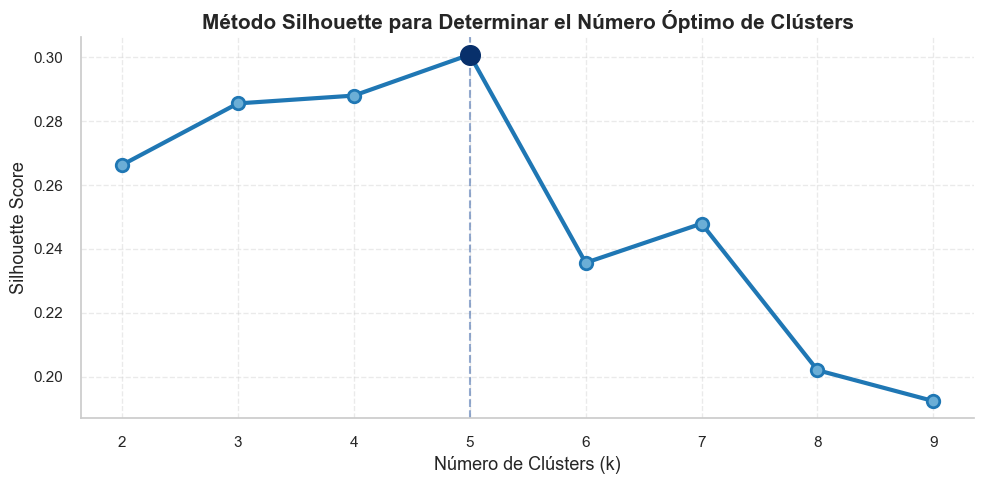

In [17]:

sns.set_style("whitegrid")

scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
    kmeans.fit(X)
    score = silhouette_score(X, kmeans.labels_, metric='euclidean')
    scores.append(score)

scores = np.array(scores)

best_k = list(K_range)[scores.argmax()]
best_score = scores.max()

plt.figure(figsize=(10,5))

blue_main = "#1f77b4"
blue_light = "#6baed6"

plt.plot(
    list(K_range),
    scores,
    marker='o',
    markersize=9,
    linewidth=3,
    color=blue_main,
    markerfacecolor=blue_light,
    markeredgewidth=2
)

#esto es para resaltar el mejor k
plt.scatter(best_k, best_score, s=200, color="#08306b", zorder=3)
plt.axvline(best_k, linestyle="--", alpha=0.6)

plt.xlabel("Número de Clústers (k)", fontsize=13)
plt.ylabel("Silhouette Score", fontsize=13)
plt.title("Método Silhouette para Determinar el Número Óptimo de Clústers", fontsize=15, weight="bold")

plt.xticks(list(K_range))
plt.grid(True, linestyle="--", alpha=0.4)

sns.despine()

plt.tight_layout()
plt.show()



<p style="
    background: linear-gradient(90deg, #4a90e2, #50c0f0);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    font-size: 16px;
    font-weight: 700;
    margin: 20px 0;
    border-bottom: 2px solid #50c0f0;
    display: inline-block;
    padding-bottom: 5px;
">
    Anteriormente con el método ELBOW buscaba el punto donde añadir no reduce el tamaño del clúster, sin embargo el Silhouette Score evalúa qué tan separados están los grupos entre sí, donde en este caso los países se separan de forma más clara con 5 que en lugar de 3 como en el anterior, también hay que tener en cuenta los datos con PCA y sin este, que se comprabará más adelante 
    
</p>

c:\Users\nicki\miniconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\nicki\miniconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\nicki\miniconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\nicki\miniconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarn

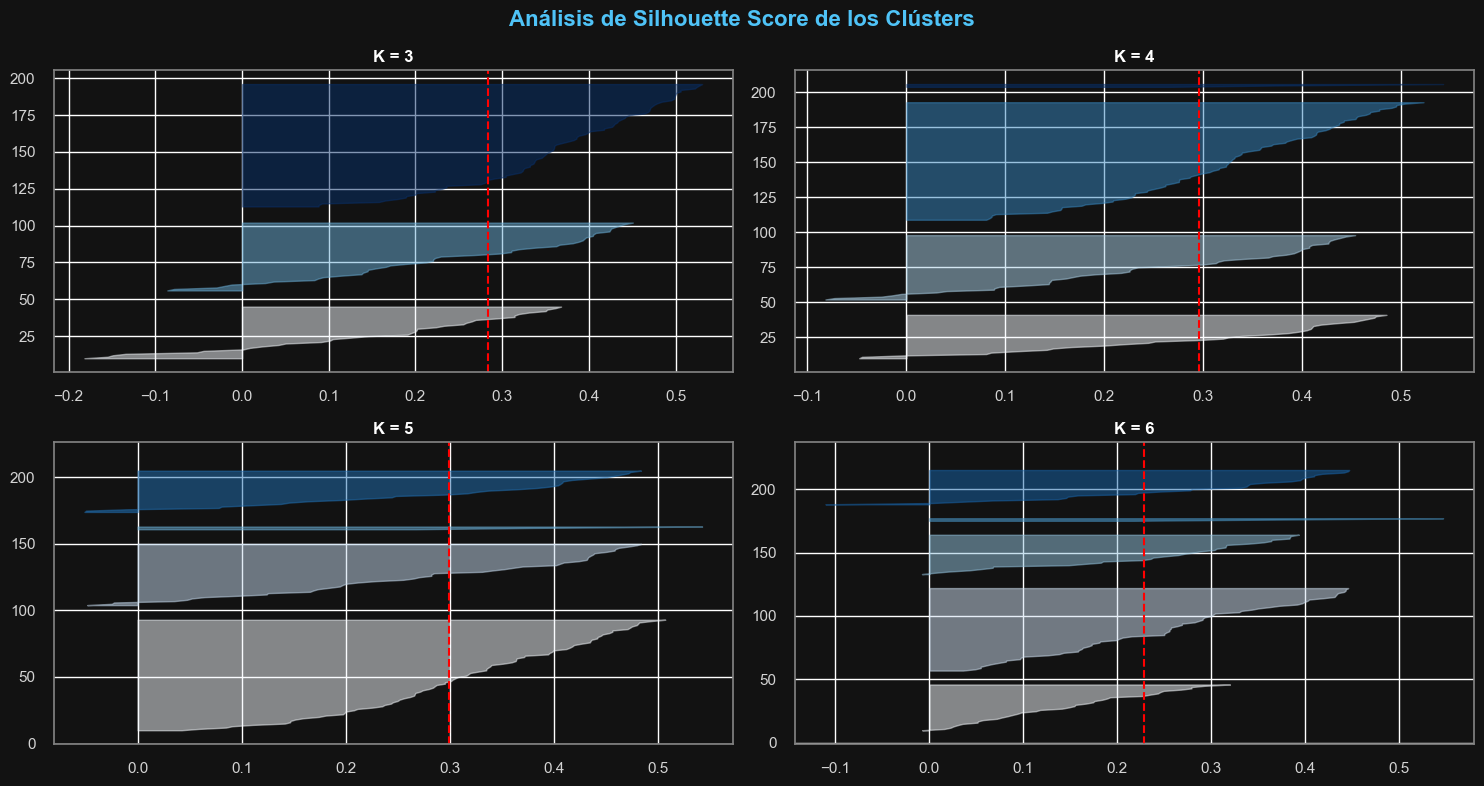

In [18]:

plt.style.use('dark_background')

fig, ax = plt.subplots(2, 2, figsize=(15, 8))
fig.patch.set_facecolor('#121212') 

k_values = [3, 4, 5, 6]

for i, k in enumerate(k_values):
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=100, random_state=42)
    
    fila = i // 2
    columna = i % 2
    
    ax[fila][columna].set_facecolor('#121212')
    
    # Al usar 'Blues' sobre fondo negro, los azules resaltarán muchísimo más
    visualizer = SilhouetteVisualizer(km, colors='Blues', ax=ax[fila][columna])
    visualizer.fit(X)
    
    ax[fila][columna].set_title(f"K = {k}", color="white", fontsize=12, weight="bold")
    
    ax[fila][columna].tick_params(colors='lightgray')
    for spine in ax[fila][columna].spines.values():
        spine.set_color('gray')

fig.suptitle("Análisis de Silhouette Score de los Clústers", color="#4fc3f7", fontsize=16, weight="bold")

plt.tight_layout()
plt.show()

plt.style.use('default')

In [19]:
k = 4

<p style="
    background: linear-gradient(90deg, #4a90e2, #50c0f0);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    font-size: 16px;
    font-weight: 700;
    margin: 20px 0;
    display: inline-block;
    padding-bottom: 5px;
">
  Tras evaluar los métodos podemos ver que el valor de k podría tomar valores entre 3 y 6.   
  Descarto 5 y 6 porque los grupos ya se dividen demasiado, pienso que tomar el valor de k = 4 sería el equilibrio.
</p>

<h1 style="
    background: linear-gradient(90deg, #4a90e2, #50c0f0);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    font-size: 20px;
    font-weight: 700;
    margin: 20px 0;
    border-bottom: 2px solid #50c0f0;
    display: inline-block;
    padding-bottom: 5px;
">
    3.1.2 Creación de Modelo
</h1>

<p style="
    background: linear-gradient(90deg, #4a90e2, #50c0f0);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    font-size: 12px;
    font-weight: 700;
    margin: 20px 0;
    display: inline-block;
    padding-bottom: 5px;
">
  Usamos el parametro init con valor k-means++ que es básicamente un truco matemático para que el modelo sea más preciso y rápido
</p>

In [20]:
kmeans = KMeans(n_clusters=k, n_init='auto', init='k-means++', random_state=30)

In [21]:
kmeans_pred = kmeans.fit_predict(X)

c:\Users\nicki\miniconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


<p style="
    background: linear-gradient(90deg, #4a90e2, #50c0f0);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    font-size: 14px;
    font-weight: 700;
    margin: 20px 0;
    display: inline-block;
    padding-bottom: 5px;
">
El clúster hecho lo metemos en nuestro df
</p>

In [22]:
df_paises["cluster-kmeans"] = kmeans_pred

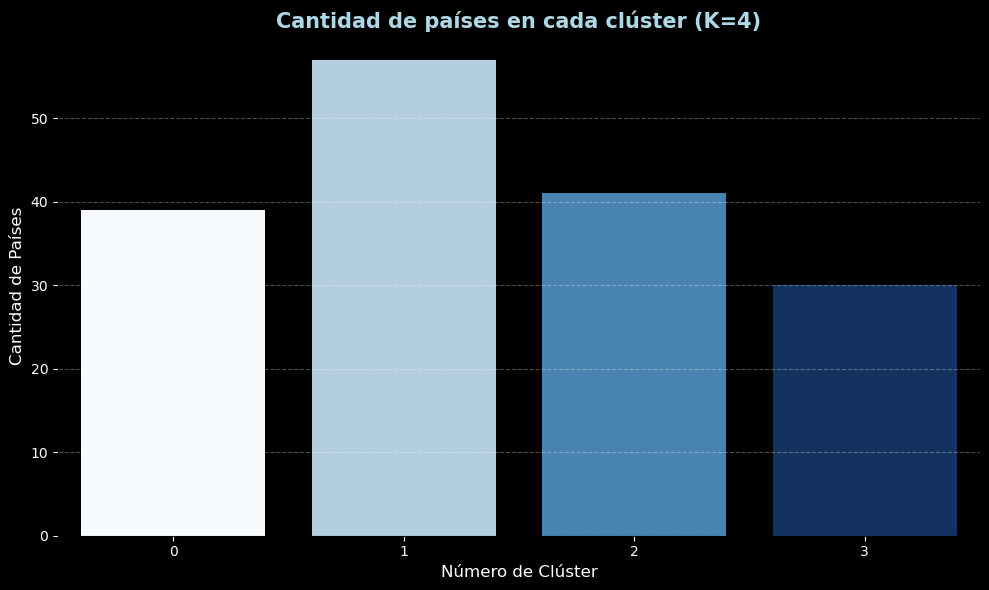

In [23]:
plt.figure(figsize=(10, 6), facecolor='black')

ax = sns.countplot(
    x='cluster-kmeans',
    data=df_paises,
    hue='cluster-kmeans',
    palette='Blues',
    legend=False
)

ax.set_facecolor('black')

plt.title('Cantidad de países en cada clúster (K=4)', fontsize=15, weight='bold', color='lightblue')
plt.xlabel('Número de Clúster', fontsize=12, color='white')
plt.ylabel('Cantidad de Países', fontsize=12, color='white')

ax.tick_params(colors='white')

plt.grid(axis='y', linestyle='--', alpha=0.3, color='white')

plt.tight_layout()
plt.show()

<p style="
    background: linear-gradient(90deg, #4a90e2, #50c0f0);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    font-size: 14px;
    font-weight: 700;
    margin: 20px 0;
    display: inline-block;
    padding-bottom: 5px;
">
Ya entrenado, en este gráfico nos permite verficar visualemnte el tamaño de cada grupo. 
Clúster 0-2 más o menos estan la misma magnitud .
Clúster 1 como vemos es el grupo mayoritario donde representa el gran conjunto de países del mundo, posiblemente podría ser los países en vías de desarrollo.
Clúster 3 sería el que tiene menor cantidad de países 

</p>

In [24]:
print("--- TABLA DE PAÍSES POR CLÚSTER ---")

diccionario_clusters = {}

for cluster_id in sorted(df_paises['cluster-kmeans'].unique()):
    
    paises = df_paises[df_paises['cluster-kmeans'] == cluster_id].index.tolist()
    
    nombre_columna = f'Clúster {cluster_id} ({len(paises)})'
    
    diccionario_clusters[nombre_columna] = pd.Series(paises)

#el fillna es porque como cada clúster tiene una cantidad diferente de países, al convertirlo a tabla, las filas que no tienen país se llenan con NaN. Con fillna('') las convertimos en celdas vacías para que quede más bonito.
tabla_paises = pd.DataFrame(diccionario_clusters).fillna('')

display(tabla_paises)

--- TABLA DE PAÍSES POR CLÚSTER ---


,Clúster 0 (39),Clúster 1 (57),Clúster 2 (41),Clúster 3 (30)
0,Algeria,Albania,Afghanistan,Australia
1,Argentina,Antigua and Barbuda,Angola,Austria
2,Armenia,Bahamas,Benin,Belgium
3,Azerbaijan,Bahrain,Botswana,Brunei
4,Bangladesh,Barbados,Burkina Faso,Canada
5,Bolivia,Belarus,Burundi,Cyprus
6,Brazil,Belize,Cameroon,Denmark
7,China,Bhutan,Central African Republic,Finland
8,Colombia,Bosnia and Herzegovina,Chad,France
9,Dominican Republic,Bulgaria,Comoros,Germany


<p style="
    background: linear-gradient(90deg, #4a90e2, #50c0f0);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    font-size: 14px;
    font-weight: 700;
    margin: 20px 0;
    display: inline-block;
    padding-bottom: 5px;
">
Al revisar el listado podemos ver que países pobres como Haití, Niger pertenecen al clúster 2, por otra parte, vemos países ricos como Singapore perteneciendo al clúster 3.
Como nos interesa ver los países más necesitados comprobaremos a que clúster pertencen
</p>

In [25]:
print("--- RANKING DE CLÚSTERS (De más pobre a más rico) ---")

cluster_pobreza_kmeans = df_paises.groupby('cluster-kmeans')[['ingresos', 'esp_vida', 'mort_inf', 'pib']].mean().round(2)

cluster_pobreza_kmeans = cluster_pobreza_kmeans.sort_values(by='ingresos')

display(cluster_pobreza_kmeans)

--- RANKING DE CLÚSTERS (De más pobre a más rico) ---


,ingresos,esp_vida,mort_inf,pib
cluster-kmeans,,,,
2,3488.61,58.38,97.22,1783.66
0,10515.64,71.17,33.85,4996.36
1,14874.04,73.65,16.45,8612.74
3,48740.00,80.52,4.90,46870.00


<p style="
    background: linear-gradient(90deg, #4a90e2, #50c0f0);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    font-size: 14px;
    font-weight: 700;
    margin: 20px 0;
    display: inline-block;
    padding-bottom: 5px;
">
Para automatizar la identificación del clúster de países necesitados, he calculado la media de los indicadores económicos y salud y luego ordenado de forma ascendente, entonces de esta manera podemos observar en la tabla, la gran cantidad de mortalidad infatil y el PIB, dando lugar que es el clúster 2 objetivo para Amancio
</p>

C:\Users\nicki\AppData\Local\Temp\ipykernel_8724\953583566.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


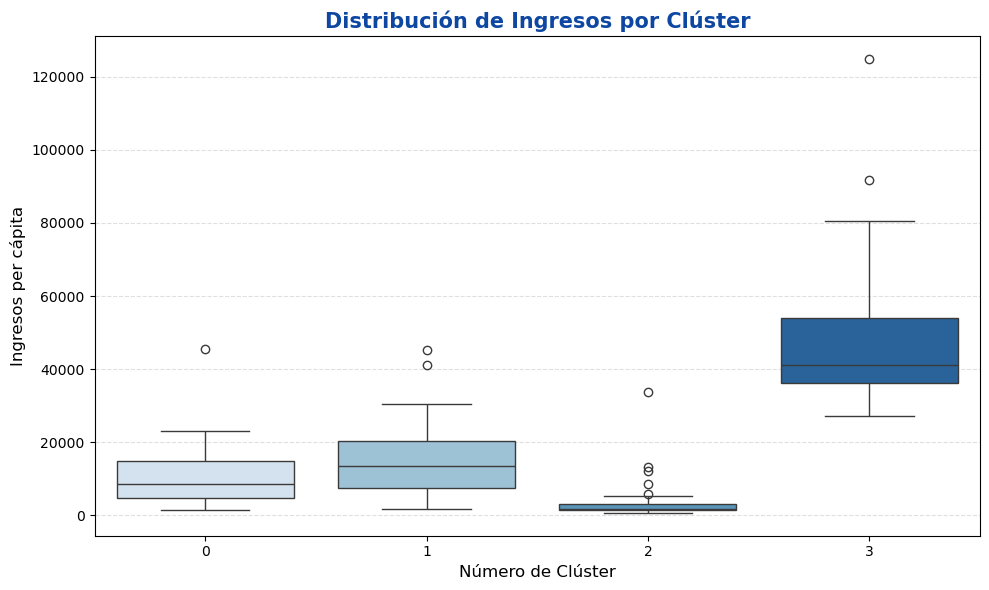

In [26]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    x='cluster-kmeans',
    y='ingresos',
    data=df_paises,
    palette='Blues'   # tonos azules
)

plt.title('Distribución de Ingresos por Clúster', fontsize=15, weight='bold', color='#0d47a1')
plt.xlabel('Número de Clúster', fontsize=12)
plt.ylabel('Ingresos per cápita', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.show()

<p style="
    background: linear-gradient(90deg, #4a90e2, #50c0f0);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    font-size: 14px;
    font-weight: 700;
    margin: 20px 0;
    display: inline-block;
    padding-bottom: 5px;
">
Como vemos el clúster 2 , observando su caja se ve que esta completamente comprimida, no hay apenas desigualdad es decir que muchos de los países tienen unos ingresos uniformemente bajos , si hay outliers pero no demasiados altos. 
<br><br>El resto de clústeres, son cajas mucho más amplias, indicándonos a medida que los ingresos suben también sube la desigualdad entre ellos.
</p>

In [27]:
num_paises_cluster_2 = df_paises[df_paises['cluster-kmeans'] == 2].shape[0]
print(f"Nnúmero de países en el Cluster 2 : {num_paises_cluster_2}")

Nnúmero de países en el Cluster 2 : 41


<p style="
    background: linear-gradient(90deg, #4a90e2, #50c0f0);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    font-size: 16px;
    font-weight: 700;
    margin: 20px 0;
    display: inline-block;
    padding-bottom: 5px;
">
Conclusiones para K-MEANS: 
</p>
<p style="
    background: linear-gradient(90deg, #4a90e2, #50c0f0);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    font-size: 14px;
    font-weight: 700;
    margin: 20px 0;
    display: inline-block;
    padding-bottom: 5px;
">
Tras entrenar el modelo de K-means con el valor k=4, vemos que el modelo es capaz de detectar la desigualdad global, teniendo 4 clústeres y el de mayor pobreza el 2, concluyendo que tienen la esperanza de vida más baja, mortalidad infatil más alta y un PIB bajo. 
</p>

## 4. PCA (2 puntos)

In [28]:
pca = PCA(n_components=0.95)
data_reduced = pca.fit_transform(X)

In [29]:
print(f"Luego de aplicar PCA pasamos de un total de {data_reduced.shape[1]} features.")

Luego de aplicar PCA pasamos de un total de 6 features.


<h1 style="
    background: linear-gradient(90deg, #4a90e2, #50c0f0);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    font-size: 15px;
    font-weight: 700;
    margin: 20px 0;
    border-bottom: 2px solid #50c0f0;
    display: inline-block;
    padding-bottom: 5px;
">
    4.1 ANÁLISIS DE VARIANZA DEFINIDA (EXPLAINED VARIANCE RATIO)
</h1>

In [30]:
pca.explained_variance_ratio_, np.sum(pca.explained_variance_ratio_) 

(array([0.4595174 , 0.17181626, 0.13004259, 0.11053162, 0.07340211,
        0.02484235]),
 np.float64(0.970152322408229))

<h1 style="
    background: linear-gradient(90deg, #4a90e2, #50c0f0);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    font-size: 14px;
    font-weight: 700;
    margin: 20px 0;
    display: inline-block;
    padding-bottom: 5px;
">
  Con esta property podemos ver cuánta información se mantiene en este caso vemos que es : <strong>0.97%</strong>
  . Por otra vemos que los dos primeros (0.45,0.17) son los que tendrían mayor peso
</h1>

<h1 style="
    background: linear-gradient(90deg, #4a90e2, #50c0f0);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    font-size: 15px;
    font-weight: 700;
    margin: 20px 0;
    border-bottom: 2px solid #50c0f0;
    display: inline-block;
    padding-bottom: 5px;
">
    4.2 ANÁLISIS DE TIEMPO DE EJECUCIÓN
</h1>

<h1 style="
    background: linear-gradient(90deg, #4a90e2, #50c0f0);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    font-size: 16px;
    font-weight: 700;
    margin: 20px 0;
    display: inline-block;
    padding-bottom: 5px;
">
    a. K-means
</h1>

In [31]:
%timeit -n1 -r1 kmeans.fit(X)

5.81 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


c:\Users\nicki\miniconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


<h1 style="
    background: linear-gradient(90deg, #4a90e2, #50c0f0);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    font-size: 14px;
    font-weight: 700;
    margin: 20px 0;
    display: inline-block;
    padding-bottom: 5px;
">
    El tiempo llevado sin PCA es de : 5.9 s
</h1>

In [32]:
%timeit -n1 -r1 kmeans.fit(data_reduced)

5.28 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


c:\Users\nicki\miniconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


<h1 style="
    background: linear-gradient(90deg, #4a90e2, #50c0f0);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    font-size: 14px;
    font-weight: 700;
    margin: 20px 0;
    display: inline-block;
    padding-bottom: 5px;
">
    El tiempo llevado con PCA es de : 3.61 s
</h1>

<h1 style="
    background: linear-gradient(90deg, #4a90e2, #50c0f0);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    font-size: 15px;
    font-weight: 700;
    margin: 20px 0;
    border-bottom: 2px solid #50c0f0;
    display: inline-block;
    padding-bottom: 5px;
">
    4.3 ENTRENAMIENTO DE MODELOS CON PCA
</h1>

<h1 style="
    background: linear-gradient(90deg, #4a90e2, #50c0f0);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    font-size: 14px;
    font-weight: 700;
    margin: 20px 0;
    display: inline-block;
    padding-bottom: 5px;
">
    K-means
</h1>

In [33]:
kmeans_pred_pca = kmeans.fit_predict(data_reduced)

c:\Users\nicki\miniconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [34]:
df_paises["cluster-kmeans-pca"] = kmeans_pred_pca

In [35]:
cluster_pobreza_kmeans_pca = (
    df_paises
    .groupby('cluster-kmeans-pca')[['ingresos', 'esp_vida', 'mort_inf', 'pib']]
    .mean()
    .sort_values(by='ingresos')
)

print("\n" + "="*50)
print("Resumen de Clústeres (KMeans + PCA)")
print("="*50)

print(cluster_pobreza_kmeans_pca.round(2))

print("\n" + "="*50)
print("Resumen de Clústeres (KMeans)")
print("="*50)

print(cluster_pobreza_kmeans.round(2))


Resumen de Clústeres (KMeans + PCA)
                    ingresos  esp_vida  mort_inf       pib
cluster-kmeans-pca                                        
2                    3539.84     59.06     95.11   1766.71
0                   12589.19     72.62     22.31   6444.33
1                   37948.15     80.40      4.54  41481.48
3                   66288.89     78.82      7.77  45700.00

Resumen de Clústeres (KMeans)
                ingresos  esp_vida  mort_inf       pib
cluster-kmeans                                        
2                3488.61     58.38     97.22   1783.66
0               10515.64     71.17     33.85   4996.36
1               14874.04     73.65     16.45   8612.74
3               48740.00     80.52      4.90  46870.00


In [36]:
num_paises_cluster_2 = df_paises[df_paises['cluster-kmeans-pca'] == 2].shape[0]
num_paises_cluster_2_sin_pca = df_paises[df_paises['cluster-kmeans'] == 2].shape[0]
print(f"El número de países en el Cluster 2 con PCA es: {num_paises_cluster_2}")
print(f"El número de países en el Cluster 2 sin PCA es: {num_paises_cluster_2_sin_pca}")

El número de países en el Cluster 2 con PCA es: 45
El número de países en el Cluster 2 sin PCA es: 41


In [37]:
num_paises_cluster_2 = df_paises[df_paises['cluster-kmeans-pca'] == 2].shape[0]
print(f"El número de países en el Cluster 2 es: {num_paises_cluster_2}")

El número de países en el Cluster 2 es: 45


<h1 style="
    background: linear-gradient(90deg, #4a90e2, #50c0f0);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    font-size: 14px;
    font-weight: 700;
    margin: 20px 0;
    display: inline-block;
    padding-bottom: 5px;
">
    Con el uso de PCA no solo hemos logrado simplificar el modelo reduciendo el número de dimensiones y de tiempo de ejecución sino que hemos mejorado la capacidad de separación de los grupos y pasamos la lista final de países en pobreza con 45 países.
    
</h1>

<p style="
    background: linear-gradient(90deg, #4a90e2, #50c0f0);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    font-size: 14px;
    font-weight: 700;
    margin: 20px 0;
    display: inline-block;
    padding-bottom: 5px;
">
    Podemos demostrar con la matriz de correlación con los datos originales, donde vimos que había una fuerte multicolinealidad por ejemplo entre el PIB y ingresos... lo que nos indica que usar PCA es lo adecuado, por otra parte en el análisis de varianza pudimos ver que podía retener 97% de la información utilizando menos dimensiones.
    <br></br>Con PCA hemos conseguido reducir el tiempo, dimensiones, mejorar la capacidad de separación de los grupos, al eliminar ruido de las variables redundantes.
    
</p>

## 5. Conclusiones (2 puntos)

In [38]:
# ¿Qué información le podemos hacer llegar a Amancio?